```{note}
Running the following cell will install tutorial dependencies on Google Colab only. It will have no effect on environments other than Google Colab.
```

In [ ]:
!pip install --quiet scvi-colab scvi
from scvi_colab import install

install()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.8/158.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.2/115.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 41.6 MB/s eta 0:00:00
INFO     scvi-colab: Installing scvi-tools.                                                                        
INFO     scvi-colab: Install successful. Testing import.                                     

/usr/local/lib/python3.12/dist-packages/pyro/ops/stats.py:527: SyntaxWarning: invalid escape sequence '\g'
  we have :math:`ES^{*}(P,Q) \ge ES^{*}(Q,Q)` with equality holding if and only if :math:`P=Q`, i.e.


In [ ]:
import os
import tempfile

import scanpy as sc
import scvi
import seaborn as sns
import torch
import anndata as ad
import mudata as mu

In [ ]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


Last run with scvi-tools version: 1.4.2


```{note}
You can modify `save_dir` below to change where the data files for this tutorial are saved.
```

In [ ]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

## Loading and preparing data

Let us first load a subsampled version of the heart cell atlas dataset described in Litviňuková et al. (2020). scvi-tools has many "built-in" datasets as well as support for loading arbitrary `.csv`, `.loom`, and `.h5ad` (AnnData) files. Please see our tutorial on data loading for more examples.

- Litviňuková, M., Talavera-López, C., Maatz, H., Reichart, D., Worth, C. L., Lindberg, E. L., ... & Teichmann, S. A. (2020). Cells of the adult human heart. Nature, 588(7838), 466-472.

```{important}
All scvi-tools models require AnnData objects as input.
```

In [ ]:
import torch
from torch import nn
import numpy as np

import sklearn

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn import datasets
import matplotlib.pyplot as plt

import warnings
import anndata as ad
import mudata as mu
import pandas as pd

RANDOM_SEED = 42

def generate_mudata(RANDOM_SEED, stdev_scaler=0.0):
    torch.manual_seed(RANDOM_SEED)

    n = 5000 # cells
    p1, p2, p3 = 50, 80, 30 # genes for each block
    k = 2

    z = torch.normal(mean=0, std=1, size=(n, k))

    true_w1 = torch.randn(p1, k)
    true_w2 = torch.randn(p2, k)
    true_w3 = torch.randn(p3, k)

     # Sparse latent
    z_sparse = z.clone()
    z_sparse[:500, 0] = 0
    z_sparse[500:, 1] = 0

    x1_sparse = z_sparse @ true_w1.T + stdev_scaler * torch.randn(n, p1)
    x2_sparse = z_sparse @ true_w2.T + stdev_scaler * torch.randn(n, p2)
    x3_sparse = z_sparse @ true_w3.T + stdev_scaler * torch.randn(n, p3)

    # Train/test split
    indices = np.arange(n)
    train_idx, test_idx = train_test_split(
        indices, test_size=0.2, random_state=RANDOM_SEED
    )

    split_labels = np.array(["train"] * n)
    split_labels[test_idx] = "test"

    # Helper to build AnnData
    def build_sparse_adata(X_sparse, name, z_sparse_data):
        adata = ad.AnnData(X=X_sparse.numpy())
        adata.layers["sparse"] = X_sparse.numpy()
        adata.obs["split"] = split_labels
        for i in range(z_sparse_data.shape[1]):
            adata.obs[f"cell_type_{i+1}"] = z_sparse_data[:, i].numpy()
        adata.var["feature"] = [f"{name}_{i}" for i in range(X_sparse.shape[1])]
        return adata

    adata1 = build_sparse_adata(x1_sparse, "mod1", z_sparse)
    adata2 = build_sparse_adata(x2_sparse, "mod2", z_sparse)
    adata3 = build_sparse_adata(x3_sparse, "mod3", z_sparse)

    mdata = mu.MuData({
        "mod1": adata1,
        "mod2": adata2,
        "mod3": adata3,
    })

    mdata.obs["split"] = adata1.obs["split"].values

    return mdata, adata1, adata2, adata3
mdata, adata1, adata2, adata3 = generate_mudata(RANDOM_SEED, stdev_scaler=0.0)

/usr/local/lib/python3.12/dist-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/usr/local/lib/python3.12/dist-packages/mudata/_core/mudata.py:571: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/usr/local/lib/python3.12/dist-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility

```{important}
Unless otherwise specified, scvi-tools models require the raw counts (not log library size normalized). scvi-tools models will run for non-negative real-valued data, but we strongly suggest checking that these possibly non-count values are intended to represent pseudocounts (e.g. SoupX-corrected counts), and not some other normalized data, in which the variance/covariance structure of the data has changed dramatically.
```

In [ ]:
import numpy as np
import scvi
import torch.nn
from scvi.data import AnnDataManager
from scvi.data.fields import CategoricalObsField, LayerField
from scvi.dataloaders import AnnDataLoader

scvi.settings.seed = 0

INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


In [ ]:
adata1.X

array([[ 0.60509306, -0.9127067 ,  0.9174078 , ...,  2.4923007 ,
        -0.08423894,  1.4736423 ],
       [-0.85661924,  1.2921022 , -1.2987576 , ..., -3.5283048 ,
         0.11925553, -2.0862086 ],
       [-0.50226754,  0.75760734, -0.7615096 , ..., -2.0687757 ,
         0.06992393, -1.2232213 ],
       ...,
       [ 0.06060462,  0.03187163, -0.05617933, ...,  0.00445471,
        -0.02260306,  0.07007729],
       [ 1.2425876 ,  0.6534699 , -1.1518551 , ...,  0.09133583,
        -0.4634348 ,  1.4368075 ],
       [ 1.0018617 ,  0.5268735 , -0.9287068 , ...,  0.07364138,
        -0.37365383,  1.1584556 ]], dtype=float32)

In [ ]:
from scvi.data.fields import LayerField, NumericalObsField

adata1 = adata1[adata1.obs["split"] == "train"].copy()
anndata_fields = [
    LayerField(
        registry_key="x",
        layer=None,
        is_count_data=False   # continuous simulated data
    ),

    NumericalObsField(
        registry_key="y1",
        attr_key="cell_type_1" #
    ),

    NumericalObsField(
        registry_key="y2",
        attr_key="cell_type_2"
    ),
]

In [ ]:
adata_manager = AnnDataManager(fields=anndata_fields)
adata_manager.register_fields(adata1)
print( adata_manager.registry.keys() ) # There is additionally a _scvi_uuid key which is used to uniquely identify AnnData objects for subsequent retrieval.

dict_keys(['scvi_version', 'model_name', 'setup_args', 'field_registries', '_scvi_uuid'])


In [ ]:
adata_manager.view_registry()

Anndata setup with scvi-tools version 1.4.2.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│       n_x        │  50   │
└──────────────────┴───────┘

               Data Registry               
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃   scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      x       │         adata.X          │
│      y1      │ adata.obs['cell_type_1'] │
│      y2      │ adata.obs['cell_type_2'] │
└──────────────┴──────────────────────────┘

In [ ]:
print(adata1)
print(f'State registry: {adata_manager.registry}')

AnnData object with n_obs × n_vars = 4000 × 50
    obs: 'split', 'cell_type_1', 'cell_type_2'
    var: 'feature'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    layers: 'sparse'
State registry: {'scvi_version': '1.4.2', 'model_name': None, 'setup_args': None, 'field_registries': defaultdict(<class 'dict'>, {'x': {'data_registry': {'attr_name': 'X', 'attr_key': None}, 'state_registry': {'n_obs': 4000, 'n_vars': 50, 'column_names': array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23',
       '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34',
       '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45',
       '46', '47', '48', '49'], dtype=object)}, 'summary_stats': {'n_x': 50}}, 'y1': {'data_registry': {'attr_name': 'obs', 'attr_key': 'cell_type_1'}, 'state_registry': {}, 'summary_stats': {}}, 'y2': {'data_registry': {'attr_name': 'obs', 'attr_key': 'cell_type_2'}, 'st

In [ ]:
# initialize an AnnDataLoader which will iterate over our anndata
adl = AnnDataLoader(adata_manager, shuffle=True, batch_size=10)

# get the first batch of data
data_batch = next(iter(adl))
data_batch['x'], data_batch['y1'], data_batch['y2']

(tensor([[ 1.7842e+00,  9.3832e-01, -1.6539e+00, -4.3435e-01,  1.9077e+00,
           3.8807e-01,  1.9891e+00,  7.6666e-02, -1.8209e+00,  5.7723e-01,
           4.5629e-01, -8.5580e-01, -5.7938e-01,  7.2308e-01, -1.3846e+00,
          -3.0856e+00,  2.2107e-01,  1.6139e+00, -1.2716e+00, -1.5033e+00,
           2.1153e+00, -3.9866e-01,  9.9905e-03, -1.5372e+00, -5.5901e-01,
          -5.1621e-01,  1.2297e+00,  7.0987e-01,  5.4020e-01, -1.8061e-01,
           8.0724e-02, -1.7122e+00, -1.7678e+00,  3.7448e-01,  2.8832e-01,
          -4.0861e-01, -1.9124e-02, -2.5038e+00, -1.9325e+00, -9.7025e-01,
           6.8028e-01, -1.9512e-01,  8.5841e-01,  7.7430e-01, -1.8300e+00,
          -1.4803e+00,  1.7944e+00,  1.3115e-01, -6.6544e-01,  2.0631e+00],
         [ 8.3189e-01,  4.3749e-01, -7.7115e-01, -2.0252e-01,  8.8944e-01,
           1.8094e-01,  9.2740e-01,  3.5746e-02, -8.4899e-01,  2.6913e-01,
           2.1275e-01, -3.9901e-01, -2.7014e-01,  3.3713e-01, -6.4558e-01,
          -1.4387e+00,  

In [ ]:
print(data_batch.keys())

dict_keys(['x', 'y1', 'y2'])


In [ ]:
# Regression model
linear_reg_model = torch.nn.Linear(adata1.X.shape[1], 2)

# Define loss and optimize
loss_fn = torch.nn.MSELoss(reduction="sum")
optim = torch.optim.Adam(linear_reg_model.parameters(), lr=0.05)


def train(x, y1, y2):
    # run the model forward on the data
    label_pred = linear_reg_model(x).squeeze(-1)
    # calculate the mse loss
    loss = loss_fn(label_pred, torch.cat([y1, y2], dim=1).squeeze(-1))
    # initialize gradients to zero
    optim.zero_grad()
    # backpropagate
    loss.backward()
    # take a gradient step
    optim.step()
    return loss

for i in range(5):
    for data in adl:
        loss = train(data['x'], data["y1"], data['y2'])
    print(f"[iteration {i + 1}] loss: {loss.item()}")

[iteration 1] loss: 2.359055519104004
[iteration 2] loss: 0.00016251699707936496
[iteration 3] loss: 0.35237592458724976
[iteration 4] loss: 6.365530014038086
[iteration 5] loss: 0.0016476494492962956


### Base Model in PyTorch

In [ ]:
# _constants.py
REGISTRY_KEYS = {
    "MOD1_KEY": "mod1",
    "MOD2_KEY": "mod2",
    "MOD3_KEY": "mod3",
}

In [ ]:
# _module.py
import torch
import torch.nn as nn
import torch.nn.functional as F

from scvi.module.base import BaseModuleClass, LossOutput


class SMBPLSModule(BaseModuleClass):

    def __init__(
        self,
        block_dims: dict,
        latent_dim: int = 2,
        sparsity_lambda: float = 1e-3,
    ):
        super().__init__()

        self.block_dims = block_dims
        self.latent_dim = latent_dim
        self.sparsity_lambda = sparsity_lambda

        # block weight matrices
        self.block_weights = nn.ParameterDict(
            {
                name: nn.Parameter(torch.randn(dim, latent_dim))
                for name, dim in block_dims.items()
            }
        )

    def _get_inference_input(self, tensors):
        return {"tensors": tensors}


    def _get_generative_input(self, tensors, inference_outputs):
        return {
            "tensors": tensors,
            "inference_outputs": inference_outputs,
        }

    def inference(self, tensors):

        latents = {}

        for block, W in self.block_weights.items():

            x = tensors[block]
            latents[block] = x @ W

        return {"latents": latents}

    def generative(self, tensors, inference_outputs):

        latents = inference_outputs["latents"]

        recon = {}

        for block, W in self.block_weights.items():

            z = latents[block]
            recon[block] = z @ W.T

        return {"recon": recon}

    def loss(self, tensors, inference_outputs, generative_outputs):

        recon = generative_outputs["recon"]
        latents = inference_outputs["latents"]

        # -------------------------
        # reconstruction loss
        # -------------------------
        recon_loss = 0

        for block in recon:

            x = tensors[block]
            x_hat = recon[block]

            recon_loss += F.mse_loss(x_hat, x)

        # -------------------------
        # sparsity penalty
        # -------------------------
        sparsity_penalty = 0

        for W in self.block_weights.values():
            sparsity_penalty += torch.sum(torch.abs(W))

        # -------------------------
        # multiblock covariance
        # -------------------------
        blocks = list(latents.keys())

        covariance = 0
        n_pairs = 0

        for i in range(len(blocks)):
            for j in range(i + 1, len(blocks)):

                z_i = latents[blocks[i]]
                z_j = latents[blocks[j]]

                # center
                z_i = z_i - z_i.mean(0)
                z_j = z_j - z_j.mean(0)

                # normalize for stability
                z_i = F.normalize(z_i, dim=0)
                z_j = F.normalize(z_j, dim=0)

                covariance += torch.mean(z_i * z_j, dim=0).sum()

                n_pairs += 1

        covariance = covariance / n_pairs

        # -------------------------
        # final loss
        # -------------------------
        loss = recon_loss + self.sparsity_lambda * sparsity_penalty - covariance

        return LossOutput(
            loss=loss,
            reconstruction_loss={"reconstruction": recon_loss.unsqueeze(0)}
        )

In [ ]:
# _model.py
from scvi.model.base import BaseModelClass
from scvi.data import AnnDataManager
from scvi.data.fields import MuDataLayerField
from scvi.dataloaders import DataSplitter
from scvi.train import TrainingPlan, TrainRunner

# from ._module import SMBPLSModule
# from ._constants import REGISTRY_KEYS


class SMBPLS(BaseModelClass):

    @classmethod
    def setup_anndata(cls, mdata):

        fields = [

            MuDataLayerField(
                REGISTRY_KEYS["MOD1_KEY"],
                mod_key="mod1",
                layer=None,
                is_count_data=False,
            ),

            MuDataLayerField(
                REGISTRY_KEYS["MOD2_KEY"],
                mod_key="mod2",
                layer=None,
                is_count_data=False,
            ),

            MuDataLayerField(
                REGISTRY_KEYS["MOD3_KEY"],
                mod_key="mod3",
                layer=None,
                is_count_data=False,
            ),
        ]

        adata_manager = AnnDataManager(fields=fields)
        adata_manager.register_fields(mdata)

        cls.register_manager(adata_manager)

    def __init__(
        self,
        mdata,
        latent_dim: int = 2,
        sparsity_lambda: float = 1e-3,
    ):

        super().__init__(mdata)

        block_dims = {
            REGISTRY_KEYS["MOD1_KEY"]: mdata["mod1"].n_vars,
            REGISTRY_KEYS["MOD2_KEY"]: mdata["mod2"].n_vars,
            REGISTRY_KEYS["MOD3_KEY"]: mdata["mod3"].n_vars,
        }

        self.module = SMBPLSModule(
            block_dims=block_dims,
            latent_dim=latent_dim,
            sparsity_lambda=sparsity_lambda,
        )

    def train(self, max_epochs: int = 200):

        split = self.adata.obs["split"]

        train_mask = split == "train"
        test_mask = split == "test"

        train_data = self.adata[train_mask].copy()
        test_data = self.adata[test_mask].copy()

        # temporary manager for training data
        data_splitter = DataSplitter(
            self.adata_manager,
            train_size=1.0,
            validation_size=0.0,
            batch_size=128,
        )

        training_plan = TrainingPlan(self.module)

        runner = TrainRunner(
            self,
            training_plan=training_plan,
            data_splitter=data_splitter,
            max_epochs=max_epochs,
        )

        return runner()

In [ ]:
# from smbpls import SMBPLS

mdata, adata1, adata2, adata3 = generate_mudata(RANDOM_SEED)

SMBPLS.setup_anndata(mdata)

model = SMBPLS(
    mdata,
    latent_dim=2,
    sparsity_lambda=1e-3,
)

model.train(max_epochs=50)

/usr/local/lib/python3.12/dist-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/usr/local/lib/python3.12/dist-packages/mudata/_core/mudata.py:571: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/usr/local/lib/python3.12/dist-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility

Training:   0%|          | 0/50 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


In [ ]:
import torch
import matplotlib.pyplot as plt

module = model.module.cpu()
adata = model.adata

scores = {}

for block, W in module.block_weights.items():

    X = torch.tensor(
        adata.mod[block].X,
        dtype=torch.float32
    )

    scores[block] = X @ W

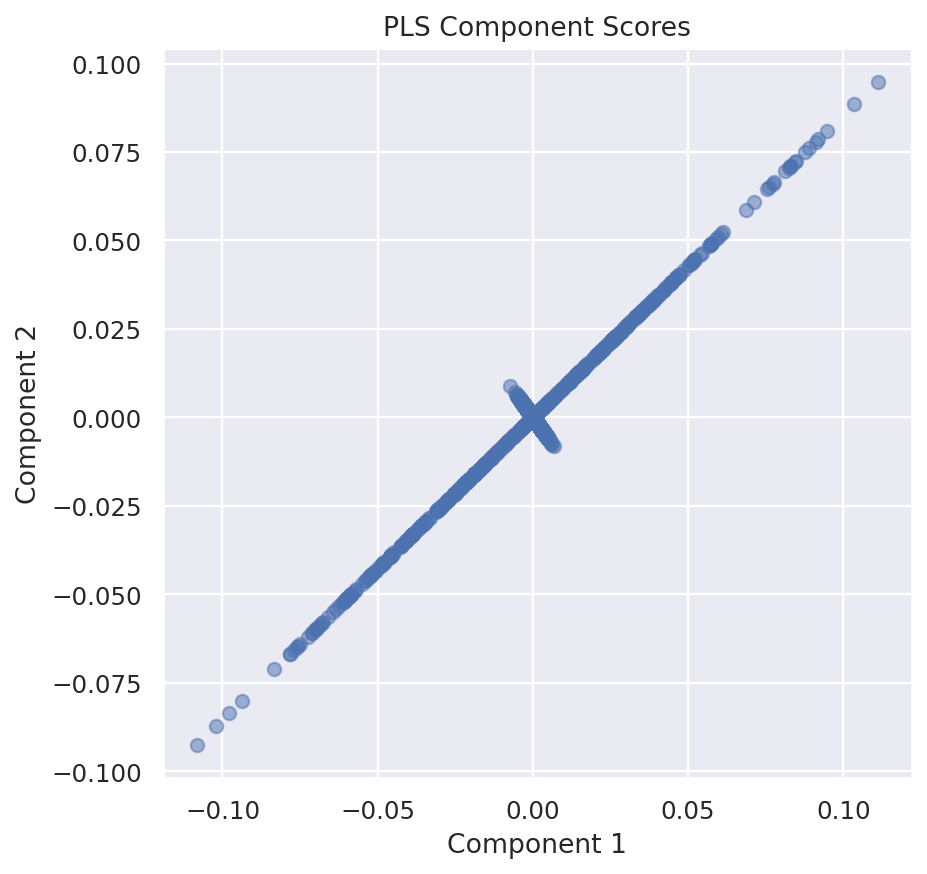

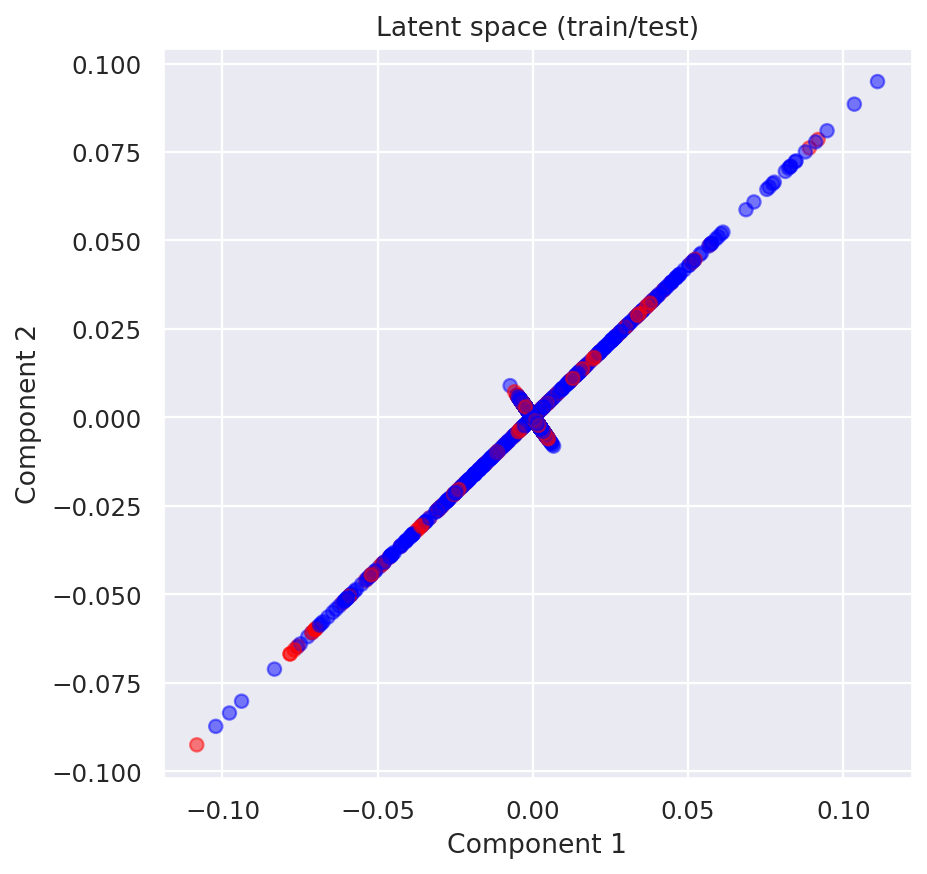

In [ ]:
z = scores["mod2"].detach().cpu().numpy()

plt.figure(figsize=(6,6))
plt.scatter(z[:,0], z[:,1], alpha=0.5)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("PLS Component Scores")
plt.show()
split = adata.obs["split"]

colors = ["blue" if s=="train" else "red" for s in split]

plt.scatter(z[:,0], z[:,1], c=colors, alpha=0.5)

plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Latent space (train/test)")
plt.show()

In [ ]:
z.shape

(5000, 2)

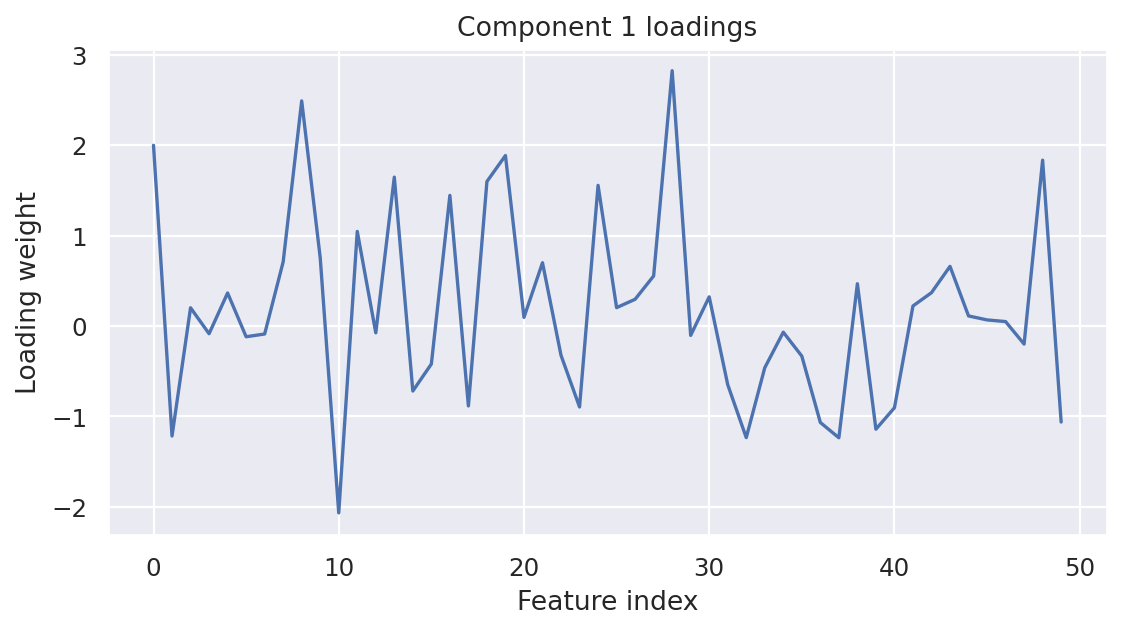

In [ ]:
W = module.block_weights["mod1"].detach().cpu().numpy()
plt.figure(figsize=(8,4))

plt.plot(W[:,0])

plt.xlabel("Feature index")
plt.ylabel("Loading weight")
plt.title("Component 1 loadings")
plt.show()